# Laboratorium 1
Kontunuacja ruchów Browna.

## Importowanie bibliotek

In [12]:
!pip install pint #run if needed

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from open_atmos_jupyter_utils import show_plot
import pint
si = pint.UnitRegistry()
si.setup_matplotlib(True)

## Dyfuzja $CO_2$ w powietrzu

Przyjmowane wartości:
- $N_A = 6.022 * 10^{23}$  [1/mol]
- $R = 8.3145$ [J/(mol K)]
- $\eta = 0.0218$ [Pa*s]=[kg /m / s]
- $T = 298.15$ [K]
- $D_{CO_2} = 0.164 * 10^{-2}$ [m$^2$/s]
- $r = 1.65 * 10^{-12}$ [m]

In [14]:
Na=6.022*10**23 / si.mole
R=8.31 * si.joule/si.kelvin/si.mole
eta=14.9* 10**(-6) * si.pascal * si.s
T=298.15 * si.K
r=165*10**(-12) * si.m
D=0.164 * si.cm**2 / si.s

t=300 * si.s
dt=0.1 * si.s

mu=0
sigma=np.sqrt(2*dt*D)

## Generowanie trajektorii dwuwymiarowego ruchu Browna macierzowo
Wszystko jest w centymetrach


In [15]:
steps = int(t/dt)
num_trajectories = 10000

jumps = np.random.normal(loc=mu,scale=sigma.magnitude, size=(2, steps, num_trajectories)) * si.m
trajectories = jumps.cumsum(axis=1) #cumulative sum for steps - last step is now a final position

In [16]:
#same as above but as a function
def generator(t, dt, num_trajectories, dim=1):
    steps = int(t/dt)
    jumps = np.random.normal(loc=mu,scale=sigma.magnitude, size=(dim, steps, num_trajectories)) * si.m
    trajectories = jumps.cumsum(axis=1)
    return trajectories

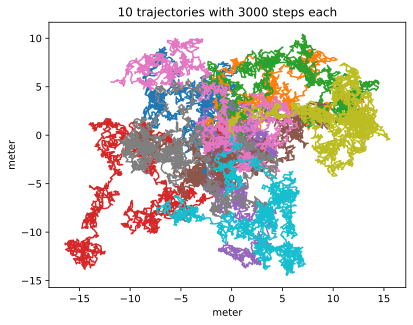

In [17]:
n_plot = 10
fig, ax = plt.subplots()
ax.plot(trajectories[0, :, :n_plot], trajectories[1, :, :n_plot]) #plot only first n_plot=10 trajectories
ax.set_title(f"{n_plot} trajectories with {steps} steps each")
show_plot(f"{n_plot}_trajectories.pdf")

## Histogram -- porównanie z teoretyczną wartością rozkładu normalnego(0,1)

In [18]:
def pdf(x, mu, sigma):
    """Probability density function for normal distribution with mu and sigma."""
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-mu)**2/(2*sigma**2))

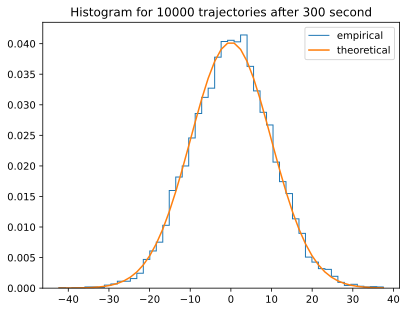

In [19]:
fig, ax = plt.subplots()
values, bins_edges =np.histogram(trajectories[0, steps-1, :].magnitude, bins=50, density=True)
ax.stairs(values=values,edges=bins_edges, label=f'empirical')
ax.plot(bins_edges, pdf(bins_edges, mu=mu, sigma=np.sqrt(steps)*sigma.magnitude),label="theoretical")
ax.set_title(f"Histogram for {num_trajectories} trajectories after {t}")
ax.legend()
show_plot(f"histogram.pdg")

Dla kilku punktów w czasie

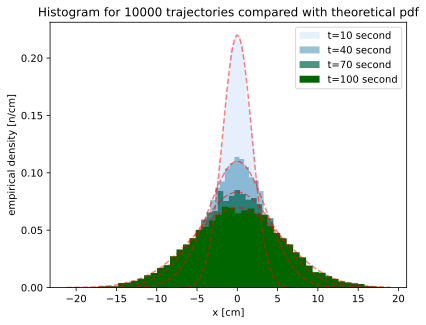

In [20]:
fig, ax = plt.subplots()
end_time = 100*si.s
num_trajectories = 10000
timepoints = np.linspace(10*si.s, end_time, 4)
trajectories = generator(end_time, dt, num_trajectories,dim=1)
for time in timepoints:
    n=int(time/dt)
    values, bins_edges =np.histogram(trajectories[0, n-1, :].magnitude, bins=50,density=True)
    ax.stairs(
        values,
        bins_edges,
        label=f't={time:.3g}',
        fill=True,
        color=(0, 0.4, 1-(time/end_time).magnitude),
        alpha=(time/end_time).magnitude
    )
    ax.plot(
        bins_edges,
        pdf(bins_edges, mu=mu, sigma=np.sqrt(n)*sigma.magnitude),
        color = 'r',
        linestyle = '--',
        alpha = 0.5
    )
ax.set_xlabel('x [cm]')
ax.set_ylabel('empirical density [n/cm]')
ax.set_title(f"Histogram for {num_trajectories} trajectories compared with theoretical pdf")
ax.legend()
show_plot(f"histogram.pdf")

## Wyznaczenie współczynnika dyfuzji z danych

In [24]:
D_empirical = np.mean(trajectories[0,-1,:]**2)/2/t
print(f"Teoretyczne D={D:.3g}\nEmpiryczne D={D_empirical.to(si.cm**2/si.s):.3g}")

Teoretyczne D=0.164 centimeter ** 2 / second
Empiryczne D=0.547 centimeter ** 2 / second


In [22]:
Na_empirical = R * T / (6 * np.pi * eta * r * D_empirical)
print(f"Teoretyczne Na={Na:.3g}\nEmpiryczne Na={Na_empirical.to_base_units():.3g}")

Teoretyczne Na=6.02e+23 / mole
Empiryczne Na=9.77e+17 / mole
